In [1]:
# Cell 1 — Env vars, imports, device
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
# Cell 2 — Load the simulated dataset saved in notebook 01
df = pd.read_csv("cmob_real.csv")
print(f"Loaded: {df.shape}")

Loaded: (8314, 9845)


In [3]:
# Cell 3 — Preprocessing: median imputation + z-score normalization
def preprocess_cmob(df, target_col="cancer_type"):
    X_raw = df.drop(columns=[target_col]).copy()
    y = df[target_col].values
    X_imputed = X_raw.fillna(X_raw.median())
    X_scaled = StandardScaler().fit_transform(X_imputed)
    return X_scaled, y

X, y = preprocess_cmob(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (6651, 9844) | Test: (1663, 9844)


In [4]:
# Cell 4 — Import SoftPermutationMix
# (copy-pasted here so this notebook is self-contained)

class SoftPermutationMix(nn.Module):
    def __init__(self, dim, K=4):
        super().__init__()
        self.dim = dim
        self.K = K
        self.alpha_logits = nn.Parameter(torch.zeros(K))
        perms = [torch.eye(dim)[torch.randperm(dim)] for _ in range(K)]
        self.register_buffer("perms", torch.stack(perms))

    def get_mixing_matrix(self):
        alpha = torch.softmax(self.alpha_logits, dim=0)
        return torch.einsum("k,kij->ij", alpha, self.perms)

    def forward(self, x):
        return x @ self.get_mixing_matrix().T

    def get_alpha(self):
        return torch.softmax(self.alpha_logits, dim=0).detach().cpu().numpy()

In [5]:
# Cell 5 — MultiOmicsNet architecture
# Each omics block gets its own encoder, then a joint representation is formed.
# When use_mix=True, a SoftPermutationMix layer routes cross-omics information.

class MultiOmicsNet(nn.Module):
    def __init__(
        self,
        n_mrna=200, n_mirna=50, n_methy=200, n_cnv=200,
        latent_dim=64, n_classes=5, use_mix=True, K=4
    ):
        super().__init__()
        self.use_mix = use_mix
        self.block_sizes = [n_mrna, n_mirna, n_methy, n_cnv]

        # Independent encoder per omics type
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(s, latent_dim),
                nn.LayerNorm(latent_dim),
                nn.GELU(),
                nn.Dropout(0.2)
            )
            for s in self.block_sizes
        ])

        joint_dim = latent_dim * len(self.block_sizes)  # 64*4 = 256

        if use_mix:
            self.mixer = SoftPermutationMix(dim=joint_dim, K=K)

        # Final classification head
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        splits = torch.split(x, self.block_sizes, dim=-1)
        latents = [enc(s) for enc, s in zip(self.encoders, splits)]
        joint = torch.cat(latents, dim=-1)
        if self.use_mix:
            joint = self.mixer(joint)
        return self.head(joint)

In [7]:
# Cell 6 — Training function
def train_model(model, X_tr, y_tr, X_te, y_te, epochs=80, lr=3e-4, label=""):
    model = model.to(device)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_te_t = torch.FloatTensor(X_te).to(device)
    y_te_t = torch.LongTensor(y_te).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = {"train_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_te_t).argmax(dim=1)
            acc = (preds == y_te_t).float().mean().item()

        history["train_loss"].append(epoch_loss / len(loader))
        history["test_acc"].append(acc)

        if (epoch + 1) % 20 == 0:
            print(f"[{label}] Epoch {epoch+1:03d} | "
                  f"Loss: {epoch_loss/len(loader):.4f} | "
                  f"Test Acc: {acc:.4f}")

    return history

In [8]:
# Cell 7 — Train both models and compare
print("=== Baseline (no SoftPermutationMix) ===")
model_base = MultiOmicsNet(
    n_mrna=3217, n_mirna=383, n_methy=3139, n_cnv=3105,
    latent_dim=64, n_classes=32, use_mix=False
)
hist_base = train_model(model_base, X_train, y_train, X_test, y_test, label="Baseline")

print("\n=== With SoftPermutationMix ===")
model_mix = MultiOmicsNet(
    n_mrna=3217, n_mirna=383, n_methy=3139, n_cnv=3105,
    latent_dim=64, n_classes=32, use_mix=True, K=4
)
hist_mix = train_model(model_mix, X_train, y_train, X_test, y_test, label="SoftPermMix")

# Save models for use in notebook 04
torch.save(model_base.state_dict(), "model_base.pt")
torch.save(model_mix.state_dict(), "model_mix.pt")
print("\nModels saved.")

=== Baseline (no SoftPermutationMix) ===
[Baseline] Epoch 020 | Loss: 0.0025 | Test Acc: 0.9741
[Baseline] Epoch 040 | Loss: 0.0022 | Test Acc: 0.9796
[Baseline] Epoch 060 | Loss: 0.0007 | Test Acc: 0.9790
[Baseline] Epoch 080 | Loss: 0.0000 | Test Acc: 0.9778

=== With SoftPermutationMix ===
[SoftPermMix] Epoch 020 | Loss: 0.0076 | Test Acc: 0.9765
[SoftPermMix] Epoch 040 | Loss: 0.0003 | Test Acc: 0.9771
[SoftPermMix] Epoch 060 | Loss: 0.0001 | Test Acc: 0.9771
[SoftPermMix] Epoch 080 | Loss: 0.0001 | Test Acc: 0.9771

Models saved.


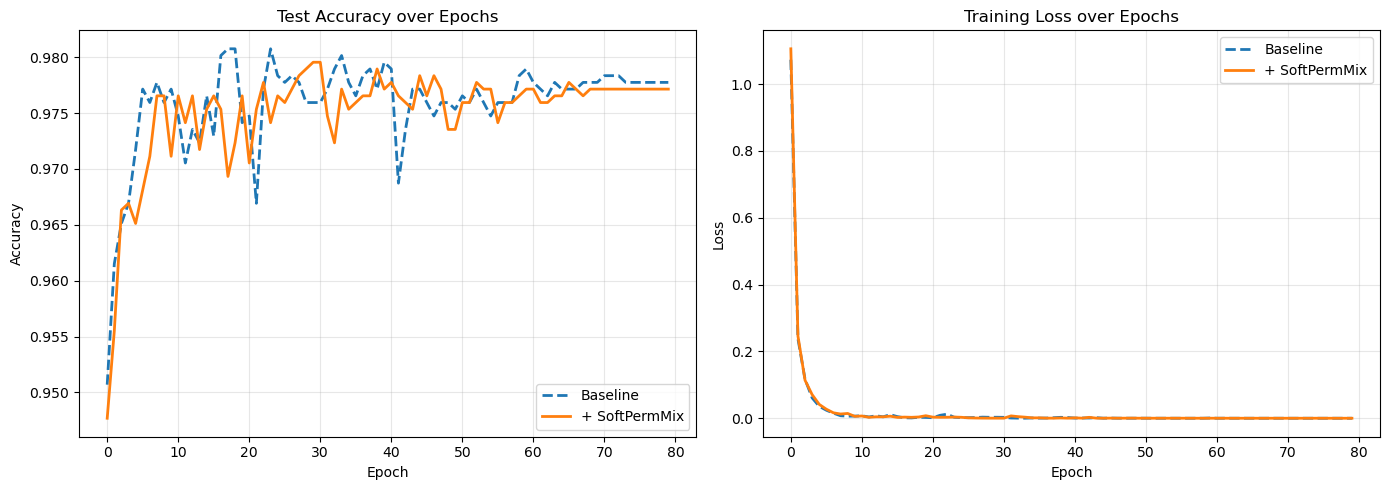

In [9]:
# Cell 8 — Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_base["test_acc"],  label="Baseline",     linewidth=2, linestyle="--")
axes[0].plot(hist_mix["test_acc"],   label="+ SoftPermMix",linewidth=2)
axes[0].set_title("Test Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_base["train_loss"], label="Baseline",     linewidth=2, linestyle="--")
axes[1].plot(hist_mix["train_loss"],  label="+ SoftPermMix",linewidth=2)
axes[1].set_title("Training Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_training_curves.png", dpi=150)
plt.show()